# Predictive modeling

## Objective and limitations

Build an interpretable Bad-outcome classification comparison, using only L2 Logistic Regression and a shallow Decision Tree. Cleaning, EDA and SQL analysis precede this stage; no dashboard is implemented.

The 1,000 historical granted-credit records deliberately oversample Bad outcomes. Scores represent modeled **Bad-outcome probability within this sample**, not contemporary population default probabilities. Earlier EDA and SQL inspected the entire dataset: the test partition is a locked modeling holdout, not a pristine independent external sample. Freeze all choices before final test evaluation; do not retune after seeing it.

All artifacts below are regenerated deterministically under `reports/modeling/` and `images/modeling/`; source data, prior notebooks and SQL outputs are read-only. See [sklearn pipelines](https://scikit-learn.org/stable/modules/compose.html) and the [corrected UCI documentation](https://archive.ics.uci.edu/dataset/573/south+german+credit+update).

In [1]:
import os
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix, make_scorer, roc_curve, precision_recall_curve)

%matplotlib inline
SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

def find_project_root():
    configured_root = os.environ.get("CREDIT_RISK_PROJECT_ROOT")
    candidates = (
        [Path(configured_root).expanduser().resolve()]
        if configured_root
        else [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    )
    for candidate in candidates:
        if (candidate / "data/raw/SouthGermanCredit.asc").is_file() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError(
        "Cannot locate the repository. Set CREDIT_RISK_PROJECT_ROOT to its directory."
    )


project_root = find_project_root()
protected_paths = [project_root / "data/processed/south_german_credit_clean.csv",
                   project_root / "notebooks/01_data_cleaning.ipynb",
                   project_root / "notebooks/02_exploratory_analysis.ipynb",
                   *sorted((project_root / "sql/results").glob("*.csv"))]
protected_hashes = {p: hashlib.sha256(p.read_bytes()).hexdigest() for p in protected_paths}
report_dir = project_root / "reports/modeling"
figure_dir = project_root / "images/modeling"
report_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(project_root / "data/processed/south_german_credit_clean.csv")
if df.empty or df.isna().any().any():
    raise ValueError("Expected a nonempty cleaned dataset without missing values.")
if not df.credit_risk.isin([0, 1]).all() or not df.credit_risk_label.equals(df.credit_risk.map({0: "Bad", 1: "Good"})):
    raise ValueError("Unexpected target codes or inconsistent display labels.")
# The index is a source-row audit identifier, never a predictor.
df.index = pd.Index(np.arange(1, len(df) + 1), name="source_row_position")


def save_table(table, filename, index=False):
    table.to_csv(report_dir / filename, index=index, lineterminator="\n", float_format="%.12g")


def save_figure(fig, filename):
    fig.savefig(figure_dir / filename, dpi=140, bbox_inches="tight", metadata={"Software": "credit-risk-analytics"})
    plt.show()
    plt.close(fig)


## Modeling target

The CSV uses **0 = Bad, 1 = Good**. Create a notebook-only target with **is_bad = 1 for Bad, 0 for Good**, so every positive-class metric and score refers to Bad outcomes. `credit_risk_label` is display-only. All target representations and technical row identifiers are excluded from predictors.

In [2]:
y = df.credit_risk.eq(0).astype(int).rename("is_bad")
display(y.value_counts().sort_index().rename_axis("is_bad").rename("records").to_frame())

,records
is_bad,
0,700
1,300


## Feature definitions

Use exactly the 18 approved predictors. Ordinal codes are ordered bands but do not imply equal spacing; encode them categorically. The category dictionaries use the corrected UCI code table already embedded in EDA/SQL. No target-derived review flags, quartiles, or duration bands enter the model.

Binary mapping: `people_liable` code 1 means three or more dependents (indicator 1); code 2 means zero to two (indicator 0). `telephone` code 2 means a registered phone (indicator 1), code 1 means none (indicator 0). Fixed semantic mappings use no outcome statistics.

In [3]:
quantitative = ["duration_months", "credit_amount", "age"]
ordinal = ["employment_duration", "installment_rate", "residence_duration", "property", "number_credits", "job"]
nominal = ["checking_status", "credit_history", "purpose", "savings", "other_debtors", "other_installment_plans", "housing"]
binary = ["people_liable", "telephone"]
categorical = ordinal + nominal
features = quantitative + categorical + binary
excluded = {"credit_risk", "credit_risk_label", "is_bad", "record_id", "personal_status_sex", "foreign_worker"}
assert len(features) == 18 and not excluded.intersection(features)
allowed_codes = {'checking_status': [1, 2, 3, 4], 'credit_history': [0, 1, 2, 3, 4], 'purpose': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'savings': [1, 2, 3, 4, 5], 'employment_duration': [1, 2, 3, 4, 5], 'installment_rate': [1, 2, 3, 4], 'personal_status_sex': [1, 2, 3, 4], 'other_debtors': [1, 2, 3], 'residence_duration': [1, 2, 3, 4], 'property': [1, 2, 3, 4], 'other_installment_plans': [1, 2, 3], 'housing': [1, 2, 3], 'number_credits': [1, 2, 3, 4], 'job': [1, 2, 3, 4], 'people_liable': [1, 2], 'telephone': [1, 2], 'foreign_worker': [1, 2]}
category_labels = {'checking_status': {1: 'no checking account', 2: '... < 0 DM', 3: '0<= ... < 200 DM', 4: '... >= 200 DM / salary for at least 1 year'}, 'credit_history': {0: 'delay in paying off in the past', 1: 'critical account/other credits elsewhere', 2: 'no credits taken/all credits paid back duly', 3: 'existing credits paid back duly till now', 4: 'all credits at this bank paid back duly'}, 'purpose': {0: 'others', 1: 'car (new)', 2: 'car (used)', 3: 'furniture/equipment', 4: 'radio/television', 5: 'domestic appliances', 6: 'repairs', 7: 'education', 8: 'vacation', 9: 'retraining', 10: 'business'}, 'savings': {1: 'unknown/no savings account', 2: '... <  100 DM', 3: '100 <= ... <  500 DM', 4: '500 <= ... < 1000 DM', 5: '... >= 1000 DM'}, 'employment_duration': {1: 'unemployed', 2: '< 1 yr', 3: '1 <= ... < 4 yrs', 4: '4 <= ... < 7 yrs', 5: '>= 7 yrs'}, 'installment_rate': {1: '>= 35', 2: '25 <= ... < 35', 3: '20 <= ... < 25', 4: '< 20'}, 'other_debtors': {1: 'none', 2: 'co-applicant', 3: 'guarantor'}, 'property': {1: 'unknown / no property', 2: 'car or other', 3: 'building soc. savings agr./life insurance', 4: 'real estate'}, 'housing': {1: 'for free', 2: 'rent', 3: 'own'}, 'residence_duration': {1: '<1 year', 2: '1–<4 years', 3: '4–<7 years', 4: '≥7 years'}, 'number_credits': {1: '1 credit', 2: '2–3 credits', 3: '4–5 credits', 4: '≥6 credits'}, 'job': {1: 'unemployed/unskilled non-resident', 2: 'unskilled resident', 3: 'skilled employee/official', 4: 'manager/self-employed/highly qualified'}}
category_labels["other_installment_plans"] = {1: "bank", 2: "stores", 3: "none"}
unknown_codes = []
for variable in categorical + binary:
    unknown = sorted(set(df[variable]) - set(allowed_codes[variable]))
    unknown_codes.append({"variable": variable, "unexpected_codes": str(unknown), "unexpected_records": int((~df[variable].isin(allowed_codes[variable])).sum())})
unknown_report = pd.DataFrame(unknown_codes)
display(unknown_report)
if unknown_report.unexpected_records.sum():
    raise ValueError("Unexpected category codes: inspect the report above.")
X = df.loc[:, features].copy()
display(pd.DataFrame({"type": ["quantitative", "ordinal", "nominal", "binary"],
                      "predictors": [", ".join(v) for v in [quantitative, ordinal, nominal, binary]]}))

,variable,unexpected_codes,unexpected_records
0,employment_duration,[],0
1,installment_rate,[],0
2,residence_duration,[],0
3,property,[],0
4,number_credits,[],0
5,job,[],0
6,checking_status,[],0
7,credit_history,[],0
8,purpose,[],0
9,savings,[],0


,type,predictors
0,quantitative,"duration_months, credit_amount, age"
1,ordinal,"employment_duration, installment_rate, residen..."
2,nominal,"checking_status, credit_history, purpose, savi..."
3,binary,"people_liable, telephone"


## Locked train/test split

Stratify and shuffle using seed 42, reserving 20% for the final test. The last 200 source rows are all Bad; neither row order nor row position can be a feature. Save source positions and split membership for reproducibility, but do not inspect test performance during development.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, shuffle=True, random_state=SEED)
split_counts = pd.DataFrame([
    {"split": name, "total": len(target), "Bad": int(target.sum()), "Good": int((1 - target).sum())}
    for name, target in [("train", y_train), ("test", y_test)]
])
assert split_counts[["total", "Bad", "Good"]].values.tolist() == [[800, 240, 560], [200, 60, 140]]
assert set(X_train.index).isdisjoint(X_test.index) and len(X_train) + len(X_test) == len(df)
display(split_counts)
split_positions = pd.DataFrame({"source_row_position": df.index,
                                "split": ["train" if i in X_train.index else "test" for i in df.index]})
save_table(split_positions, "split_positions.csv")
display(split_positions.head())
print("All 1,000 split positions saved to reports/modeling/split_positions.csv; not included in X.")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_splits = list(cv.split(X_train, y_train))
assert all(int(y_train.iloc[v].sum()) == 48 for _, v in cv_splits)
print("Five identical CV splits: each validation fold has 160 records, including 48 Bad.")

,split,total,Bad,Good
0,train,800,240,560
1,test,200,60,140


,source_row_position,split
0,1,train
1,2,test
2,3,train
3,4,train
4,5,test


All 1,000 split positions saved to reports/modeling/split_positions.csv; not included in X.
Five identical CV splits: each validation fold has 160 records, including 48 Bad.


## Preprocessing

Each candidate is a complete `Pipeline` with a `ColumnTransformer`: quantitative scaling, log1p (or the single raw comparison) for amount, full one-hot encoding of ordinal/nominal variables, and fixed binary mapping. Scalers are fitted only on the current training fold. No imputation or target encoding is used.

Allowed categories come from the external codebook; this declares possible levels without learning full-data frequencies. `handle_unknown="ignore"` is a defensive fallback, but unexpected codes are explicitly reported and rejected above. Levels absent from a training fold have no fitted category-specific evidence. No rare groups are merged.

Both model families use the same preprocessing; scaling is unnecessary for trees but keeps the shared representation reproducible. Log1p reduces skew without recovering original loan values.

In [5]:
def map_binary(values):
    values = np.asarray(values)
    return np.column_stack([values[:, 0] == 1, values[:, 1] == 2]).astype(float)


def make_preprocessor(log_amount=True):
    amount_steps = []
    if log_amount:
        amount_steps.append(("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")))
    amount_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("numeric", StandardScaler(), ["duration_months", "age"]),
        ("amount", Pipeline(amount_steps), ["credit_amount"]),
        ("categories", OneHotEncoder(categories=[allowed_codes[v] for v in categorical],
                                    handle_unknown="ignore", drop=None, sparse_output=False), categorical),
        ("binary", FunctionTransformer(map_binary, feature_names_out="one-to-one"), binary),
    ], remainder="drop", verbose_feature_names_out=True)


def make_model(family, log_amount=True, C=1.0, max_depth=3, min_samples_leaf=20):
    estimator = (LogisticRegression(C=C, solver="lbfgs", max_iter=3000, random_state=SEED)
                 if family == "logistic" else
                 DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=SEED))
    return Pipeline([("preprocess", make_preprocessor(log_amount)), ("model", estimator)])


def bad_probabilities(model, data):
    positive_index = list(model.classes_).index(1)
    return model.predict_proba(data)[:, positive_index]


def evaluate(target, probabilities, threshold=0.50):
    prediction = np.asarray(probabilities) >= threshold
    tn, fp, fn, tp = confusion_matrix(target, prediction, labels=[0, 1]).ravel()
    return {"accuracy": accuracy_score(target, prediction),
            "bad_precision": tp / (tp + fp) if tp + fp else float("nan"),
            "bad_recall": tp / (tp + fn), "bad_f1": f1_score(target, prediction, zero_division=0),
            "specificity": tn / (tn + fp), "roc_auc": roc_auc_score(target, probabilities),
            "average_precision": average_precision_score(target, probabilities),
            "brier_score": brier_score_loss(target, probabilities),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "flagged_pct": 100 * prediction.mean()}

scoring = {"accuracy": "accuracy", "average_precision": "average_precision", "roc_auc": "roc_auc",
           "bad_precision": make_scorer(precision_score, zero_division=0),
           "bad_recall": make_scorer(recall_score), "bad_f1": make_scorer(f1_score, zero_division=0),
           "neg_brier": "neg_brier_score"}


def cv_statistics(model):
    scores = cross_validate(model, X_train, y_train, cv=cv_splits, scoring=scoring,
                            return_train_score=True, n_jobs=1, error_score="raise")
    output = {}
    for metric in scoring:
        name = "brier_score" if metric == "neg_brier" else metric
        sign = -1 if metric == "neg_brier" else 1
        for partition in ["train", "test"]:
            prefix = "train" if partition == "train" else "validation"
            values = scores[f"{partition}_{metric}"] * sign
            output[f"{prefix}_{name}_mean"] = values.mean()
            output[f"{prefix}_{name}_std"] = values.std(ddof=1)
    return output


## Baselines

`most_frequent` always predicts Good and obtains 70% accuracy while detecting zero Bad outcomes. `prior` assigns the training prevalence as a constant score. These benchmarks must be surpassed through useful discrimination, not accuracy alone.

Precision is undefined when no records are flagged (displayed as NaN/blank). CV scorers use zero in this case solely to produce computable fold summaries. Constant-score ROC-AUC is 0.5; AP is approximately 0.3. AP is the sklearn non-interpolated average-precision metric, not trapezoidal PR-AUC.

In [6]:
baseline_models = {name: DummyClassifier(strategy=name, random_state=SEED) for name in ["most_frequent", "prior"]}
baseline_development = []
for name, model in baseline_models.items():
    probabilities = cross_val_predict(model, X_train, y_train, cv=cv_splits, method="predict_proba", n_jobs=1)[:, 1]
    baseline_development.append({"baseline": name, **evaluate(y_train, probabilities)})
baseline_table = pd.DataFrame(baseline_development)
display(baseline_table)
save_table(baseline_table, "baseline_training_oof.csv")

,baseline,accuracy,bad_precision,bad_recall,bad_f1,specificity,roc_auc,average_precision,brier_score,tn,fp,fn,tp,flagged_pct
0,most_frequent,0.7,NaN,0.0,0.0,1.0,0.5,0.3,0.30,560,0,240,0,0.0
1,prior,0.7,NaN,0.0,0.0,1.0,0.5,0.3,0.21,560,0,240,0,0.0


## Candidate models

Implement exactly two model families without class weighting. Logistic Regression uses L2 regularization with C = 0.1, 1, 10; compare only logged versus raw-scaled amount. Tree candidates use max_depth = 2, 3, 4 and min_samples_leaf = 20, 40, retaining the approved logged-amount preprocessing. All random seeds are 42. No additional models or derived SQL features are added.

In [7]:
candidate_models = {}
candidate_metadata = {}
for log_amount in [True, False]:
    for C in [0.1, 1, 10]:
        name = f"logistic_{'log' if log_amount else 'raw'}_C{C}"
        candidate_models[name] = make_model("logistic", log_amount=log_amount, C=C)
        candidate_metadata[name] = {"family": "logistic", "amount_transform": "log1p" if log_amount else "raw", "C": C}
for depth in [2, 3, 4]:
    for leaf in [20, 40]:
        name = f"tree_depth{depth}_leaf{leaf}"
        candidate_models[name] = make_model("tree", max_depth=depth, min_samples_leaf=leaf)
        candidate_metadata[name] = {"family": "tree", "amount_transform": "log1p", "max_depth": depth, "min_samples_leaf": leaf}
assert len(candidate_models) == 12
print("12 configurations × 5 folds. All preprocessing is fitted inside each fold.")

12 configurations × 5 folds. All preprocessing is fitted inside each fold.


## Cross-validation and selection

Compare mean AP on the identical training folds. Report sample standard deviation across folds, plus ROC-AUC, Bad precision/recall/F1, Brier score and training-versus-validation behavior. Fold variability is not a formal confidence interval. Hyperparameter-search scores are development estimates and can be optimistic.

Choose the best AP configuration in each family; tied configurations use their predeclared insertion order. If family AP differs by ≤0.02, prefer Logistic Regression; otherwise select the higher-AP family. The amount transformation is chosen through the same training-only AP search. Freeze the selected configuration now.

In [8]:
cv_rows = []
for name, model in candidate_models.items():
    cv_rows.append({"candidate": name, **candidate_metadata[name], **cv_statistics(model)})
cv_results = pd.DataFrame(cv_rows)
save_table(cv_results, "cv_candidates.csv")
best_names = {family: cv_results.loc[cv_results.family.eq(family)].sort_values(
    "validation_average_precision_mean", ascending=False, kind="stable").iloc[0].candidate for family in ["logistic", "tree"]}
family_summary = cv_results.set_index("candidate").loc[list(best_names.values())].reset_index()
display(family_summary[["candidate", "validation_average_precision_mean", "validation_average_precision_std",
                        "validation_roc_auc_mean", "validation_bad_precision_mean", "validation_bad_recall_mean",
                        "validation_bad_f1_mean", "validation_brier_score_mean", "train_average_precision_mean"]])
save_table(family_summary, "cv_family_summary.csv")
display(cv_results[["candidate", "validation_average_precision_mean", "validation_average_precision_std",
                    "validation_roc_auc_mean", "validation_roc_auc_std", "validation_bad_precision_mean", "validation_bad_precision_std",
                    "validation_bad_recall_mean", "validation_bad_recall_std", "validation_bad_f1_mean", "validation_bad_f1_std",
                    "validation_brier_score_mean", "validation_brier_score_std", "train_average_precision_mean", "train_average_precision_std"]])
amount_comparison = cv_results[cv_results.family.eq("logistic")].groupby("amount_transform", sort=False).apply(
    lambda group: group.sort_values("validation_average_precision_mean", ascending=False, kind="stable").iloc[0], include_groups=False
).reset_index()
display(amount_comparison[["amount_transform", "candidate", "validation_average_precision_mean", "validation_average_precision_std"]])
log_ap = float(family_summary.loc[family_summary.family.eq("logistic"), "validation_average_precision_mean"].iloc[0])
tree_ap = float(family_summary.loc[family_summary.family.eq("tree"), "validation_average_precision_mean"].iloc[0])
selected_family = "logistic" if abs(log_ap - tree_ap) <= 0.02 or log_ap > tree_ap else "tree"
selected_name = best_names[selected_family]
print(f"Frozen selection: {selected_name}; Logistic AP={log_ap:.4f}, Tree AP={tree_ap:.4f}.")
print("Logistic amount representation selected by training CV:", candidate_metadata[best_names["logistic"]]["amount_transform"])
selection = {"selected_candidate": selected_name, "selected_family": selected_family,
             "selected_parameters": candidate_metadata[selected_name], "best_logistic": best_names["logistic"],
             "best_tree": best_names["tree"], "logistic_cv_ap": log_ap, "tree_cv_ap": tree_ap,
             "seed": SEED, "test_size": 0.20, "simplicity_tolerance": 0.02}


,candidate,validation_average_precision_mean,validation_average_precision_std,validation_roc_auc_mean,validation_bad_precision_mean,validation_bad_recall_mean,validation_bad_f1_mean,validation_brier_score_mean,train_average_precision_mean
0,logistic_raw_C0.1,0.621594,0.059277,0.784152,0.633336,0.383333,0.470612,0.166019,0.703859
1,tree_depth4_leaf40,0.466442,0.034055,0.716574,0.518852,0.387500,0.432479,0.189415,0.540763


,candidate,validation_average_precision_mean,validation_average_precision_std,validation_roc_auc_mean,validation_roc_auc_std,validation_bad_precision_mean,validation_bad_precision_std,validation_bad_recall_mean,validation_bad_recall_std,validation_bad_f1_mean,validation_bad_f1_std,validation_brier_score_mean,validation_brier_score_std,train_average_precision_mean,train_average_precision_std
0,logistic_log_C0.1,0.618898,0.047622,0.782589,0.039656,0.610847,0.064975,0.383333,0.082811,0.466034,0.059924,0.166440,0.011524,0.700607,0.011904
1,logistic_log_C1,0.603913,0.039156,0.769643,0.034600,0.584382,0.046514,0.441667,0.077111,0.497451,0.034783,0.173172,0.012373,0.722183,0.007477
2,logistic_log_C10,0.591113,0.036874,0.763765,0.032643,0.574408,0.049347,0.462500,0.077111,0.506912,0.038614,0.177619,0.012586,0.722292,0.006917
3,logistic_raw_C0.1,0.621594,0.059277,0.784152,0.044121,0.633336,0.084056,0.383333,0.089122,0.470612,0.059423,0.166019,0.013616,0.703859,0.015640
4,logistic_raw_C1,0.605756,0.054077,0.770573,0.038767,0.590860,0.051902,0.466667,0.073065,0.516667,0.034085,0.173030,0.015129,0.725460,0.013247
5,logistic_raw_C10,0.596057,0.050441,0.765365,0.036812,0.589184,0.059041,0.475000,0.078506,0.520945,0.039664,0.177731,0.015151,0.727214,0.012369
6,tree_depth2_leaf20,0.438467,0.030466,0.704204,0.018241,0.432022,0.263883,0.208333,0.131762,0.273190,0.160166,0.187091,0.008094,0.464389,0.011718
7,tree_depth2_leaf40,0.438698,0.030328,0.704669,0.017949,0.432022,0.263883,0.208333,0.131762,0.273190,0.160166,0.186951,0.008111,0.464474,0.011629
8,tree_depth3_leaf20,0.448011,0.027043,0.706231,0.027038,0.533283,0.104870,0.308333,0.179457,0.365231,0.108356,0.190592,0.009880,0.513771,0.018955
9,tree_depth3_leaf40,0.455416,0.027021,0.714565,0.025648,0.533283,0.104870,0.308333,0.179457,0.365231,0.108356,0.187384,0.008414,0.502642,0.021049


,amount_transform,candidate,validation_average_precision_mean,validation_average_precision_std
0,log1p,logistic_log_C0.1,0.618898,0.047622
1,raw,logistic_raw_C0.1,0.621594,0.059277


Frozen selection: logistic_raw_C0.1; Logistic AP=0.6216, Tree AP=0.4664.
Logistic amount representation selected by training CV: raw


## Training-only threshold analysis

Use only training out-of-fold probabilities for the frozen selected configuration. Compare five preset thresholds; preserve 0.50 as the standard reference. Select the best F1 among the four non-0.50 thresholds as an illustrative alternative (ties prefer the higher threshold), while reporting whether it improves on 0.50. This is not a financial-cost optimization: no cost information is available.

These OOF probabilities exclude each record from estimator/preprocessor fitting, but the configuration was selected using training CV. Therefore these are development diagnostics, not an unbiased final performance estimate. Freeze the alternative before any test results are shown.

In [9]:
selected_oof = cross_val_predict(candidate_models[selected_name], X_train, y_train,
                                cv=cv_splits, method="predict_proba", n_jobs=1)[:, 1]
threshold_table = pd.DataFrame([{"threshold": threshold, **evaluate(y_train, selected_oof, threshold)}
                                for threshold in [0.20, 0.30, 0.40, 0.50, 0.60]])
display(threshold_table[["threshold", "bad_precision", "bad_recall", "bad_f1", "specificity", "fp", "fn", "flagged_pct"]])
save_table(threshold_table, "training_thresholds.csv")
alternative = threshold_table[threshold_table.threshold.ne(0.50)].sort_values(
    ["bad_f1", "threshold"], ascending=[False, False], kind="stable").iloc[0]
alternative_threshold = float(alternative.threshold)
selection["reference_threshold"] = 0.50
selection["illustrative_threshold"] = alternative_threshold
selection["illustrative_oof_f1"] = float(alternative.bad_f1)
(report_dir / "selection.json").write_text(json.dumps(selection, sort_keys=True, indent=2) + "\n")
print(f"Frozen illustrative threshold: {alternative_threshold:.2f}; training OOF F1={alternative.bad_f1:.4f}.")
print("Reference OOF F1:", threshold_table.loc[threshold_table.threshold.eq(0.50), "bad_f1"].iloc[0])

,threshold,bad_precision,bad_recall,bad_f1,specificity,fp,fn,flagged_pct
0,0.2,0.424431,0.854167,0.567082,0.503571,278,35,60.375
1,0.3,0.522124,0.737500,0.611399,0.710714,162,63,42.375
2,0.4,0.576132,0.583333,0.579710,0.816071,103,100,30.375
3,0.5,0.621622,0.383333,0.474227,0.900000,56,148,18.500
4,0.6,0.655172,0.237500,0.348624,0.946429,30,183,10.875


Frozen illustrative threshold: 0.30; training OOF F1=0.6114.
Reference OOF F1: 0.4742268041237113


## Model interpretation

Fit the frozen best configuration of each family on all 800 training records. Interpretation below uses training data only. L2 coefficients are conditional associations, not causal effects.

With all one-hot levels retained, the meaningful categorical contrast is **beta(category) − beta(reference)** and its odds ratio is exp(contrast). Numeric odds ratios correspond to one training-standard-deviation increase in the processed variable; binary odds ratios compare indicator 1 against 0. An amount coefficient refers to the selected raw or log representation. Sparse/unobserved levels receive caution flags and are excluded from the strongest-association display. Coefficient magnitudes are not global feature-importance rankings.

,variable,comparison,coefficient_contrast,odds_ratio,category_n,reference_n,sparse_flag
26,purpose,purpose: car (new) vs others,-1.028406,0.357576,85,189,0
28,purpose,purpose: furniture/equipment vs others,-0.598543,0.549612,231,189,0
34,purpose,purpose: retraining vs others,-0.521520,0.593617,67,189,0
10,property,property: unknown / no property vs real estate,-0.507541,0.601974,232,121,0
4,installment_rate,installment_rate: >= 35 vs < 20,-0.435989,0.646625,111,380,0
22,credit_history,credit_history: delay in paying off in the pas...,0.807909,2.243212,33,226,0
36,savings,savings: unknown/no savings account vs ... >= ...,0.819871,2.270207,475,148,0
23,credit_history,credit_history: critical account/other credits...,0.984947,2.677670,42,226,0
20,checking_status,checking_status: ... < 0 DM vs ... >= 200 DM /...,1.052722,2.865439,221,316,0
19,checking_status,checking_status: no checking account vs ... >=...,1.376602,3.961420,217,316,0


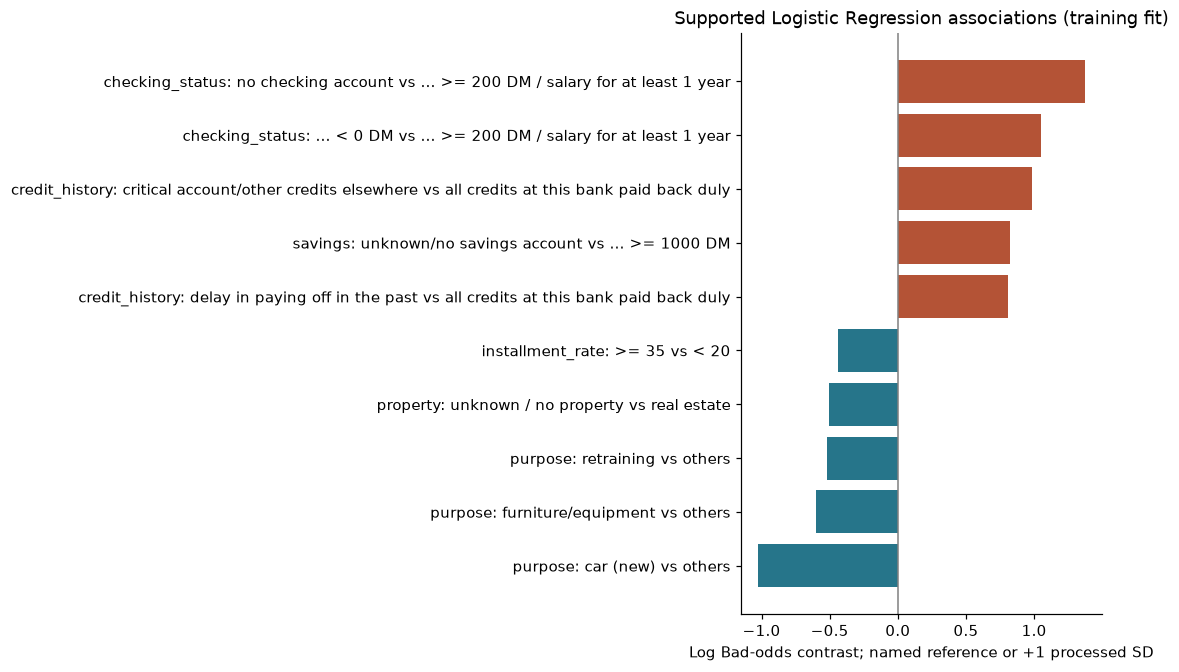

,leaf,rule,training_records,training_bad_share,sparse_flag
0,4,checking_status is not ... >= 200 DM / salary ...,46,0.369565,0
1,5,checking_status is not ... >= 200 DM / salary ...,40,0.025000,0
2,7,checking_status is not ... >= 200 DM / salary ...,91,0.571429,0
3,8,checking_status is not ... >= 200 DM / salary ...,213,0.356808,0
4,10,checking_status is not ... >= 200 DM / salary ...,51,0.529412,0
5,11,checking_status is not ... >= 200 DM / salary ...,43,0.744186,0
6,15,checking_status is ... >= 200 DM / salary for ...,53,0.094340,0
7,16,checking_status is ... >= 200 DM / salary for ...,42,0.190476,0
8,18,checking_status is ... >= 200 DM / salary for ...,98,0.061224,0
9,19,checking_status is ... >= 200 DM / salary for ...,53,0.000000,0


Leaf shares are training-fit descriptions, not independent performance estimates. No impurity importance claims.


In [10]:
fitted_models = {family: candidate_models[name].fit(X_train, y_train) for family, name in best_names.items()}
logistic = fitted_models["logistic"]
preprocessor = logistic.named_steps["preprocess"]
feature_names = preprocessor.get_feature_names_out()
coefficients = dict(zip(feature_names, logistic.named_steps["model"].coef_[0]))
save_table(pd.DataFrame({"encoded_feature": feature_names, "coefficient": logistic.named_steps["model"].coef_[0]}), "logistic_coefficients.csv")
references = {"employment_duration": 5, "installment_rate": 4, "residence_duration": 4,
              "property": 4, "number_credits": 1, "job": 3, "checking_status": 4,
              "credit_history": 4, "purpose": 0, "savings": 5, "other_debtors": 1,
              "other_installment_plans": 3, "housing": 2}
association_rows = []
for variable in categorical:
    reference = references[variable]
    n_reference = int(X_train[variable].eq(reference).sum())
    for level in allowed_codes[variable]:
        if level == reference:
            continue
        n_category = int(X_train[variable].eq(level).sum())
        contrast = coefficients[f"categories__{variable}_{level}"] - coefficients[f"categories__{variable}_{reference}"]
        association_rows.append({"variable": variable,
                                 "comparison": f"{variable}: {category_labels[variable][level]} vs {category_labels[variable][reference]}",
                                 "coefficient_contrast": contrast, "odds_ratio": np.exp(contrast),
                                 "category_n": n_category, "reference_n": n_reference,
                                 "sparse_flag": int(min(n_category, n_reference) < 30)})
for name, description in [("numeric__duration_months", "duration: +1 training SD"), ("numeric__age", "age: +1 training SD"),
                          ("amount__credit_amount", f"amount ({candidate_metadata[best_names['logistic']]['amount_transform']}): +1 training SD"),
                          ("binary__people_liable", "dependents: ≥3 vs 0–2"), ("binary__telephone", "registered telephone: yes vs no")]:
    variable = name.split("__")[1]
    n_category = int(X_train[variable].eq(1 if variable == "people_liable" else 2).sum()) if variable in binary else len(X_train)
    n_reference = len(X_train) - n_category if variable in binary else len(X_train)
    association_rows.append({"variable": variable, "comparison": description, "coefficient_contrast": coefficients[name],
                             "odds_ratio": np.exp(coefficients[name]), "category_n": n_category, "reference_n": n_reference,
                             "sparse_flag": int(min(n_category, n_reference) < 30)})
associations = pd.DataFrame(association_rows)
save_table(associations, "logistic_associations.csv")
supported = associations[associations.sparse_flag.eq(0)].sort_values("coefficient_contrast", kind="stable")
interpretation_display = pd.concat([supported.head(5), supported.tail(5)]).drop_duplicates("comparison").sort_values("coefficient_contrast")
display(interpretation_display)
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
ax.barh(interpretation_display.comparison, interpretation_display.coefficient_contrast,
        color=["#26758a" if value < 0 else "#b45336" for value in interpretation_display.coefficient_contrast])
ax.axvline(0, color="gray", linewidth=1)
ax.set(title="Supported Logistic Regression associations (training fit)", xlabel="Log Bad-odds contrast; named reference or +1 processed SD")
save_figure(fig, "03_logistic_interpretation.png")

# Recover readable tree split thresholds from the shared quantitative scalers.
tree_model = fitted_models["tree"]
tree_prep = tree_model.named_steps["preprocess"]
tree = tree_model.named_steps["model"].tree_
tree_feature_names = tree_prep.get_feature_names_out()

def split_description(encoded_name, threshold, left):
    prefix, variable = encoded_name.split("__", 1)
    operator = "<=" if left else ">"
    if prefix == "categories":
        variable, level = variable.rsplit("_", 1)
        return f"{variable} {'is not' if left else 'is'} {category_labels[variable][int(level)]}"
    if prefix == "binary":
        label = "≥3 dependents" if variable == "people_liable" else "registered telephone"
        return f"{label}: {'no' if left else 'yes'}"
    if prefix == "numeric":
        scaler = tree_prep.named_transformers_["numeric"]
        index = ["duration_months", "age"].index(variable)
        raw_threshold = threshold * scaler.scale_[index] + scaler.mean_[index]
    else:
        scaler = tree_prep.named_transformers_["amount"].named_steps["scale"]
        raw_threshold = np.expm1(threshold * scaler.scale_[0] + scaler.mean_[0])
    return f"{variable} {operator} {raw_threshold:.2f}"

leaf_rows = []
def visit_node(node, conditions):
    if tree.children_left[node] == tree.children_right[node]:
        counts = tree.value[node][0]
        leaf_rows.append({"leaf": node, "rule": " AND ".join(conditions) or "All records",
                          "training_records": int(tree.n_node_samples[node]),
                          "training_bad_share": float(counts[1] / counts.sum()),
                          "sparse_flag": int(tree.n_node_samples[node] < 30)})
    else:
        feature = tree_feature_names[tree.feature[node]]
        visit_node(tree.children_left[node], conditions + [split_description(feature, tree.threshold[node], True)])
        visit_node(tree.children_right[node], conditions + [split_description(feature, tree.threshold[node], False)])
visit_node(0, [])
tree_rules = pd.DataFrame(leaf_rows)
assert tree_rules.training_records.sum() == len(X_train)
save_table(tree_rules, "tree_rules.csv")
display(tree_rules)
print("Leaf shares are training-fit descriptions, not independent performance estimates. No impurity importance claims.")

## Final test evaluation

All configurations and the illustrative threshold above are frozen. Evaluate each fixed trained family once to obtain cached test probabilities. Report the selected primary at 0.50 and the frozen alternative, plus the fixed comparator and baselines for context. Do not select another winner or retune based on these results. Confusion-matrix rows are actual outcomes and columns are predictions; **Bad is positive**.

,model,candidate,selected_primary,threshold,accuracy,bad_precision,bad_recall,bad_f1,specificity,roc_auc,average_precision,brier_score,tn,fp,fn,tp,flagged_pct
0,logistic,logistic_raw_C0.1,1,0.5,0.76,0.642857,0.450000,0.529412,0.892857,0.760238,0.605034,0.171585,125,15,33,27,21.0
1,tree,tree_depth4_leaf40,0,0.5,0.73,0.578947,0.366667,0.448980,0.885714,0.704583,0.473238,0.187042,124,16,38,22,19.0
2,most_frequent,most_frequent,0,0.5,0.70,NaN,0.000000,0.000000,1.000000,0.500000,0.300000,0.300000,140,0,60,0,0.0
3,prior,prior,0,0.5,0.70,NaN,0.000000,0.000000,1.000000,0.500000,0.300000,0.210000,140,0,60,0,0.0
4,logistic,logistic_raw_C0.1,1,0.3,0.69,0.488095,0.683333,0.569444,0.692857,0.760238,0.605034,0.171585,97,43,19,41,42.0


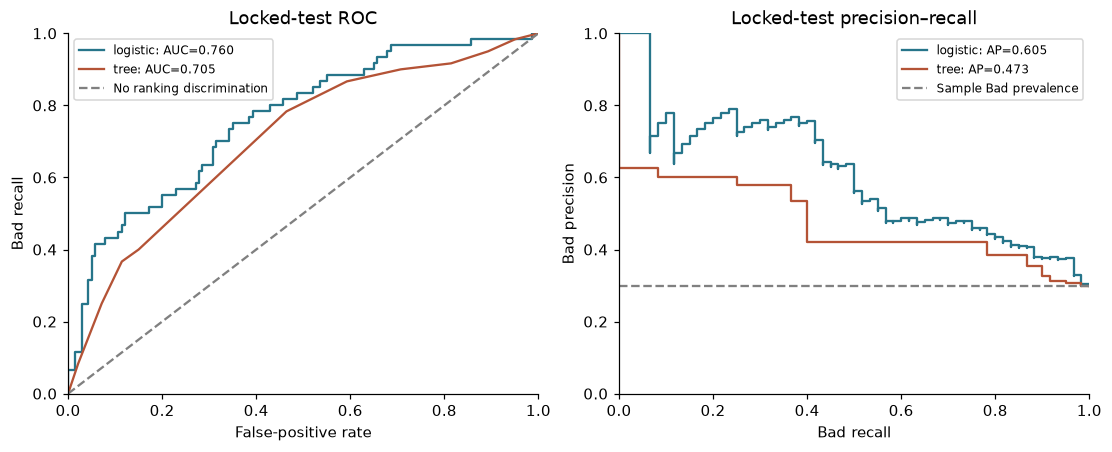

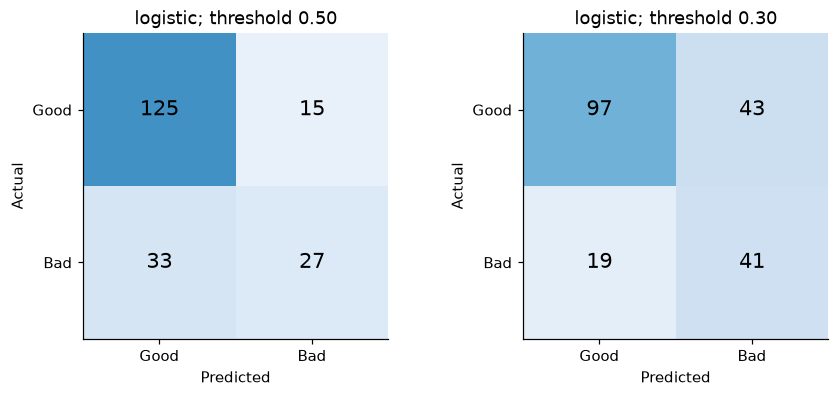

In [11]:
test_probabilities = {family: bad_probabilities(model, X_test) for family, model in fitted_models.items()}
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    test_probabilities[name] = bad_probabilities(model, X_test)
test_rows = []
for family in ["logistic", "tree", "most_frequent", "prior"]:
    test_rows.append({"model": family, "candidate": best_names.get(family, family),
                      "selected_primary": int(family == selected_family), "threshold": 0.50,
                      **evaluate(y_test, test_probabilities[family])})
test_rows.append({"model": selected_family, "candidate": selected_name, "selected_primary": 1,
                  "threshold": alternative_threshold, **evaluate(y_test, test_probabilities[selected_family], alternative_threshold)})
test_metrics = pd.DataFrame(test_rows)
display(test_metrics)
save_table(test_metrics, "test_metrics.csv")
ordered_predictions = pd.DataFrame({"source_row_position": X_test.index, "actual_is_bad": y_test.to_numpy(),
                                    **{f"{name}_bad_probability": values for name, values in test_probabilities.items()}}).sort_values("source_row_position")
save_table(ordered_predictions, "test_predictions.csv")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
colors = {"logistic": "#26758a", "tree": "#b45336"}
for family in ["logistic", "tree"]:
    p = test_probabilities[family]
    fpr, tpr, _ = roc_curve(y_test, p)
    precision, recall, _ = precision_recall_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{family}: AUC={roc_auc_score(y_test, p):.3f}", color=colors[family])
    axes[1].step(recall, precision, where="post", label=f"{family}: AP={average_precision_score(y_test, p):.3f}", color=colors[family])
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="No ranking discrimination")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Sample Bad prevalence")
axes[0].set(title="Locked-test ROC", xlabel="False-positive rate", ylabel="Bad recall", xlim=(0, 1), ylim=(0, 1))
axes[1].set(title="Locked-test precision–recall", xlabel="Bad recall", ylabel="Bad precision", xlim=(0, 1), ylim=(0, 1))
for ax in axes: ax.legend(fontsize=8)
save_figure(fig, "01_test_roc_pr.png")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), layout="constrained")
for ax, threshold in zip(axes, [0.50, alternative_threshold]):
    matrix = confusion_matrix(y_test, test_probabilities[selected_family] >= threshold, labels=[0, 1])
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=len(y_test))
    for i in range(2):
        for j in range(2): ax.text(j, i, str(matrix[i, j]), ha="center", va="center", fontsize=14)
    ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Good", "Bad"], yticklabels=["Good", "Bad"],
           title=f"{selected_family}; threshold {threshold:.2f}", xlabel="Predicted", ylabel="Actual")
save_figure(fig, "02_test_confusion_matrices.png")

## Calibration

Report Brier score alongside an approximately five-bin quantile calibration plot for the frozen selected model. Bin sizes and mean predicted/observed Bad proportions are displayed. Tied probabilities may reduce the number of bins. No recalibration or prevalence correction is performed after seeing test outcomes. Brier score reflects both discrimination and calibration.

,bin,total_records,bad_records,mean_probability,observed_bad_share
0,"(0.019799999999999998, 0.115]",40,2,0.073491,0.05
1,"(0.115, 0.207]",40,8,0.157109,0.20
2,"(0.207, 0.311]",40,12,0.253555,0.30
3,"(0.311, 0.517]",40,12,0.405468,0.30
4,"(0.517, 0.879]",40,26,0.643523,0.65


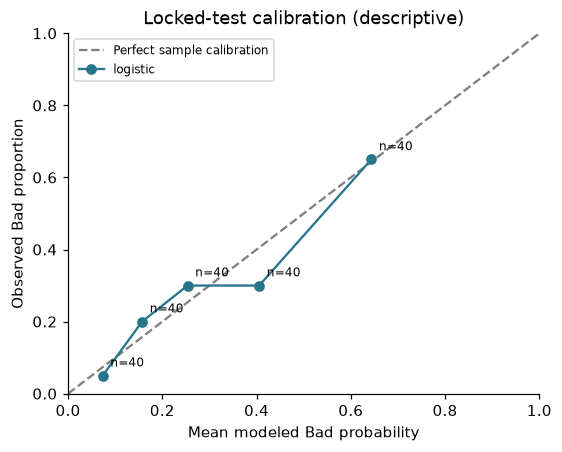

Selected-model test Brier: 0.17158549367199896


In [12]:
calibration_data = pd.DataFrame({"probability": test_probabilities[selected_family], "actual": y_test.to_numpy()})
calibration_data["bin"] = pd.qcut(calibration_data.probability, q=5, duplicates="drop")
calibration_bins = calibration_data.groupby("bin", observed=True).agg(
    total_records=("actual", "size"), bad_records=("actual", "sum"),
    mean_probability=("probability", "mean"), observed_bad_share=("actual", "mean")
).reset_index()
calibration_bins["bin"] = calibration_bins["bin"].astype(str)
assert calibration_bins.total_records.sum() == len(y_test)
display(calibration_bins)
save_table(calibration_bins, "calibration_bins.csv")
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect sample calibration")
ax.plot(calibration_bins.mean_probability, calibration_bins.observed_bad_share, "o-", color=colors[selected_family], label=selected_family)
for row in calibration_bins.itertuples():
    ax.annotate(f"n={row.total_records}", (row.mean_probability, row.observed_bad_share), xytext=(5, 6), textcoords="offset points", fontsize=8)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean modeled Bad probability", ylabel="Observed Bad proportion", title="Locked-test calibration (descriptive)")
ax.legend(fontsize=8)
save_figure(fig, "04_test_calibration.png")
print("Selected-model test Brier:", brier_score_loss(y_test, test_probabilities[selected_family]))

## Fairness and historical-data limitations

- `personal_status_sex` and `foreign_worker` remain excluded. Sex cannot reliably be recovered from the combined personal-status category. The foreign-worker subgroup has only 37 records and four Bad outcomes, too little support for strong conclusions. No sensitivity model is added.
- Exclusion does not prove fairness: other variables may act as proxies, and the data cannot establish present-day demographic parity or equitable lending behavior. Age remains a demographic predictor.
- Data date from 1973–1975, include only granted credits, and intentionally oversample Bad outcomes. All precision, calibration, and modeled probabilities are sample-specific.
- Credit amounts are transformed historical values; log1p adds a modeling representation, not a reconstruction of actual loan amounts. No exposure, expected loss or financial cost is inferred.
- Rare/empty categories yield weak or unsupported effects; L2 shrinkage is not evidence of an absent effect.
- Training CV was used for configuration and transformation selection; OOF threshold diagnostics can be optimistic. The test has only 60 Bad records, and no formal significance or causal claims are made.
- Earlier full-data EDA/SQL means the modeling holdout is not completely untouched. There are no reliable customer IDs or dates for grouped/temporal validation; independent contemporary data would be needed for stronger generalization claims.
- The 0.02 AP simplicity rule and illustrative F1 threshold are predeclared analytical choices, not a business-cost optimum. No additional tuning follows test evaluation.

## Final findings

Summarize the frozen selection, test detection trade-off and supported Logistic Regression contrasts. These findings update from the actual run; interpretation refers to Logistic Regression even if the selected primary is the tree.

In [13]:
primary_reference = test_metrics[(test_metrics.model == selected_family) & test_metrics.threshold.eq(0.50)].iloc[0]
primary_alternative = test_metrics[(test_metrics.model == selected_family) & test_metrics.threshold.eq(alternative_threshold)].iloc[0]
positive = supported.iloc[-1]
negative = supported.iloc[0]
findings = [
    f"**Frozen selection:** {selected_name}. Training CV AP: Logistic {log_ap:.3f}, Tree {tree_ap:.3f}; the 0.02 simplicity rule was applied before test evaluation.",
    f"**Locked-test discrimination:** AP {primary_reference.average_precision:.3f}, ROC-AUC {primary_reference.roc_auc:.3f}, Brier {primary_reference.brier_score:.3f}. At 0.50, Bad recall is {primary_reference.bad_recall:.1%} and precision {primary_reference.bad_precision:.1%}; accuracy alone is insufficient.",
    f"**Frozen threshold trade-off:** At {alternative_threshold:.2f}, Bad recall is {primary_alternative.bad_recall:.1%}, precision {primary_alternative.bad_precision:.1%}, FP={int(primary_alternative.fp)}, FN={int(primary_alternative.fn)}. At 0.50, FP={int(primary_reference.fp)}, FN={int(primary_reference.fn)}. This is illustrative F1-based detection, not financial optimization.",
    f"**Supported Logistic association:** {positive.comparison}; odds ratio {positive.odds_ratio:.2f}, training support {int(positive.category_n)} vs {int(positive.reference_n)}. Conditional association, not causation.",
    f"**Supported Logistic association:** {negative.comparison}; odds ratio {negative.odds_ratio:.2f}, training support {int(negative.category_n)} vs {int(negative.reference_n)}. All interpretations remain historical/sample-specific.",
]
display(Markdown("\n\n".join(f"{i}. {finding}" for i, finding in enumerate(findings, 1))))
for path, before_hash in protected_hashes.items():
    assert hashlib.sha256(path.read_bytes()).hexdigest() == before_hash, f"Protected file changed: {path}"
assert len(list(figure_dir.glob("*.png"))) == 4
assert selected_name == selection["selected_candidate"]
print("Verified: protected CSV, earlier notebooks and SQL output hashes unchanged; four primary figures; no post-test tuning.")

1. **Frozen selection:** logistic_raw_C0.1. Training CV AP: Logistic 0.622, Tree 0.466; the 0.02 simplicity rule was applied before test evaluation.

2. **Locked-test discrimination:** AP 0.605, ROC-AUC 0.760, Brier 0.172. At 0.50, Bad recall is 45.0% and precision 64.3%; accuracy alone is insufficient.

3. **Frozen threshold trade-off:** At 0.30, Bad recall is 68.3%, precision 48.8%, FP=43, FN=19. At 0.50, FP=15, FN=33. This is illustrative F1-based detection, not financial optimization.

4. **Supported Logistic association:** checking_status: no checking account vs ... >= 200 DM / salary for at least 1 year; odds ratio 3.96, training support 217 vs 316. Conditional association, not causation.

5. **Supported Logistic association:** purpose: car (new) vs others; odds ratio 0.36, training support 85 vs 189. All interpretations remain historical/sample-specific.

Verified: protected CSV, earlier notebooks and SQL output hashes unchanged; four primary figures; no post-test tuning.
